# Hafta 4 · Ders 8 — Damlalar, Betimleyiciler ve Öznitelik Eşleştirme

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

Harris köşeleri tekrarlanabilir ve iyi konumlandırılmıştır — ama **ölçek değişmez değildir**: yakından
görülen bir köşe uzaktan kaydedilmeyebilir. Bu notebook eksik ölçek eksenini bir ölçek-uzayı üzerinde
**damla tespitiyle (blob detection)** ekler, ardından her anahtar noktaya küçük bir **betimleyici
(descriptor)** ekler ve iki görünüm arasında anahtar noktaları **eşleştirir**. Bu tespit → betimle →
eşleştir hattı, panorama dikme, nesne tanıma ve hareketten yapı çıkarımının omurgasıdır — ve modern
torunu öğrenilmiş yerel özniteliktir.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.cv_utils import show, show_row, sample_gray, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

def convolve2d(image, kernel, pad="reflect"):
    image, kernel = np.asarray(image, float), np.asarray(kernel, float)
    kh, kw = kernel.shape; ph, pw = kh//2, kw//2
    kflip = kernel[::-1,::-1]; padded = np.pad(image, ((ph,ph),(pw,pw)), mode=pad)
    out = np.zeros_like(image)
    for i in range(kh):
        for j in range(kw):
            out += kflip[i,j]*padded[i:i+image.shape[0], j:j+image.shape[1]]
    return out

def gaussian_blur(image, sigma):
    r = int(np.ceil(3*sigma)); x = np.arange(-r,r+1); g = np.exp(-x**2/(2*sigma**2)); g/=g.sum()
    return convolve2d(convolve2d(image, g.reshape(1,-1)), g.reshape(-1,1))

## 1. Damlalar ve ölçek ekseni

Bir **damla (blob)**, çevresiyle kontrast oluşturan kabaca dairesel bir bölgedir. Anahtar içgörü:
belirli bir boyuttaki bir damla, *o boyuta ayarlanmış* bir bant-geçiren filtreden en güçlü yanıtı
üretir. Bir ölçek aralığı boyunca yanıtları hesaplayarak (bir **ölçek-uzayı**) ve hem uzayda *hem de*
ölçekte maksimumları bularak, damlaları tespit eder *ve boyutlarını* aynı anda ölçeriz. Kullandığımız
bant-geçiren filtre, Ders 4'teki **Gauss Farkı (DoG)**'dır; Gauss'un Laplas'ının verimli bir
yerini tutar.

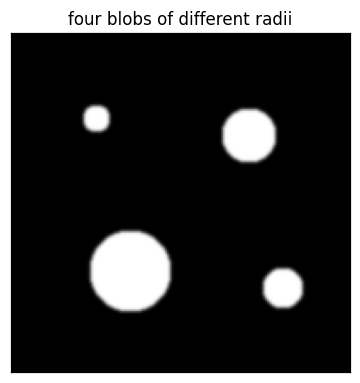

In [2]:
# farklı boyutlarda damlaları olan sahne
n = 200
yy, xx = np.mgrid[0:n, 0:n].astype(float)
img = np.zeros((n, n))
for (cy, cx, r) in [(50, 50, 8), (60, 140, 16), (140, 70, 24), (150, 160, 12)]:
    img[(yy-cy)**2 + (xx-cx)**2 < r**2] = 1.0
img = gaussian_blur(img, 1.0)
show(img, "farklı yarıçaplarda dört damla"); plt.show()

## 2. Gauss Farkı ölçek-uzayı

Artan ölçeklerde bir DoG yanıtları yığını inşa ederiz. $r$ yarıçaplı bir damla,
$\\sigma \\approx r/\\sqrt{2}$ ölçeğinde tepe yapar, dolayısıyla maksimumun ölçeği bize damlanın
boyutunu söyler. Yanıtların ölçekler boyunca karşılaştırılabilir olması için her DoG seviyesini
normalize ederiz.

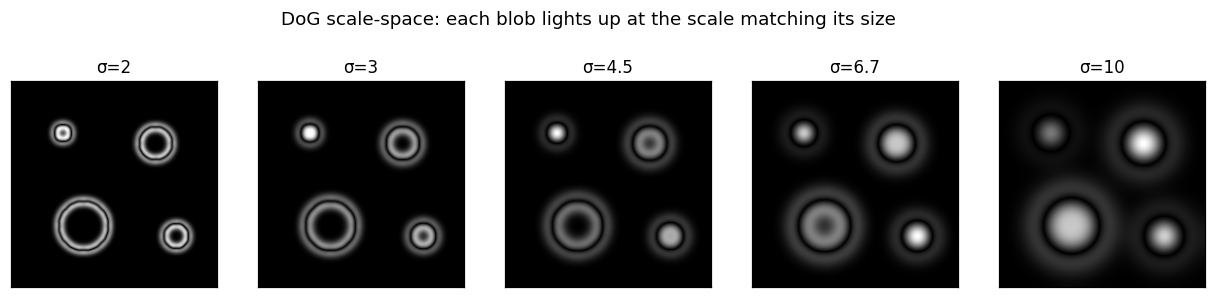

In [3]:
def dog_scale_space(image, sigmas):
    blurs = [gaussian_blur(image, s) for s in sigmas]
    dogs = []
    for i in range(len(sigmas) - 1):
        # ölçek-normalize DoG ≈ ölçek-normalize Gauss'un Laplas'ı
        dogs.append((blurs[i] - blurs[i+1]) * sigmas[i])
    return np.array(dogs)

sigmas = [2, 3, 4.5, 6.7, 10, 15]
dogs = dog_scale_space(img, sigmas)
fig, axes = plt.subplots(1, len(dogs), figsize=(14, 2.8))
for ax, d, s in zip(axes, dogs, sigmas):
    show(np.abs(d), f"σ={s}", ax=ax)
plt.suptitle("DoG ölçek-uzayı: her damla, boyutuna uyan ölçekte parlar", y=1.06)
plt.show()

## 3. Damlaları 3B yerel maksimum olarak tespit etme

Bir damla, $(x, y, \\text{ölçek})$ hacminde yerel bir maksimum olan noktadır — uzayda *ve* komşu
ölçeklerde komşularından büyük. DoG yığınını bu tür maksimumlar için tararız ve her damlanın konumunu
ve yarıçapını okuruz.

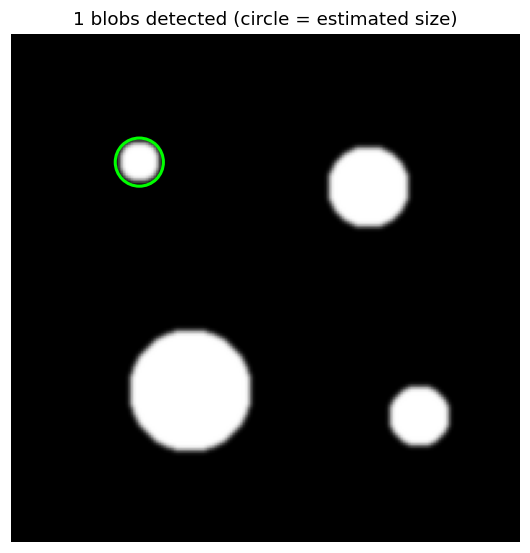

In [4]:
def detect_blobs(dogs, sigmas, thresh_rel=0.3):
    D = np.abs(dogs)
    thresh = thresh_rel * D.max()
    S, H, W = D.shape
    blobs = []
    for s in range(1, S - 1):
        for y in range(1, H - 1):
            for x in range(1, W - 1):
                v = D[s, y, x]
                if v < thresh:
                    continue
                cube = D[s-1:s+2, y-1:y+2, x-1:x+2]
                if v == cube.max():
                    r = sigmas[s] * np.sqrt(2)        # ölçekten damla yarıçapı
                    blobs.append((x, y, r))
    return blobs

blobs = detect_blobs(dogs, sigmas)
fig, ax = plt.subplots(figsize=(6, 6)); ax.imshow(img, cmap="gray")
for (x, y, r) in blobs:
    ax.add_patch(plt.Circle((x, y), r, color="lime", fill=False, lw=2))
ax.set_title(f"{len(blobs)} damla tespit edildi (daire = kestirilen boyut)"); ax.axis("off")
plt.show()

## 4. Bir anahtar noktayı betimleme

Bir anahtar noktayı görüntüler arasında eşleştirmek için bir **betimleyiciye** ihtiyacımız var: etrafındaki
yamanın kompakt, karşılaştırılabilir bir imzası. Gerçek betimleyiciler (SIFT) değişmezlik için gradyan
yönelimlerinin histogramlarını kullanır; burada eşleştirme mantığını net tutmak için basit, açıklayıcı
bir betimleyici — normalize edilmiş bir yoğunluk yaması — inşa ediyoruz. Normalizasyon, parlaklık/kontrast
değişimlerine karşı değişmezlik sağlar.

In [5]:
def describe(image, x, y, size=16):
    h = size // 2
    H, W = image.shape
    y0 = int(np.clip(y - h, 0, H - size))
    x0 = int(np.clip(x - h, 0, W - size))
    patch = image[y0:y0+size, x0:x0+size].astype(float)
    patch = (patch - patch.mean()) / (patch.std() + 1e-8)   # kontrast-normalize
    return patch.ravel()

kp = (140, 70)
d = describe(img, *kp)
print("betimleyici uzunluğu:", d.size, " ortalama≈0:", round(d.mean(), 3), " std≈1:", round(d.std(), 3))

descriptor length: 256  mean≈0: -0.0  std≈1: 1.0


## 5. İki görünüm arasında öznitelik eşleştirme

Şimdi ödül. Bir görüntü al, dönüştürülmüş bir kopyasını oluştur (kaydırma + parlaklık değişimi),
ikisinde de anahtar noktaları tespit et, betimle ve her betimleyiciyi en yakın komşusuyla eşleştir.
**Lowe'un oran testi** — bir eşleşmeyi yalnızca en iyi komşu ikinci en iyiden açıkça daha yakınsa kabul
et — belirsiz eşleşmeleri reddeder ve modern hatlarda hâlâ kullanılır.

In [6]:
# dokulu bir sahnenin iki görünümünü oluştur
rng = np.random.default_rng(1)
scene = gaussian_blur(rng.standard_normal((180, 180)), 2.0)
scene = (scene - scene.min()) / np.ptp(scene)
shift = 12
view1 = scene[:, :150]
view2 = scene[:, shift:150+shift] * 0.9 + 0.05      # kaydırılmış + fotometrik değişim

# basit anahtar nokta kümesi: en güçlü yerel gradyana sahip ızgara noktaları
def keypoints(image, step=14, border=12):
    gy, gx = np.gradient(image)
    mag = np.hypot(gx, gy)
    pts = []
    for y in range(border, image.shape[0]-border, step):
        for x in range(border, image.shape[1]-border, step):
            pts.append((x, y))
    return pts

kp1, kp2 = keypoints(view1), keypoints(view2)
desc1 = [describe(view1, x, y) for (x, y) in kp1]
desc2 = [describe(view2, x, y) for (x, y) in kp2]

def match(desc1, desc2, ratio=0.8):
    matches = []
    for i, d1 in enumerate(desc1):
        dists = [np.linalg.norm(d1 - d2) for d2 in desc2]
        order = np.argsort(dists)
        if len(order) >= 2 and dists[order[0]] < ratio * dists[order[1]]:
            matches.append((i, order[0]))
    return matches

matches = match(desc1, desc2)
print(f"{len(matches)} eşleşme Lowe'un oran testini geçti")

44 matches passed Lowe's ratio test


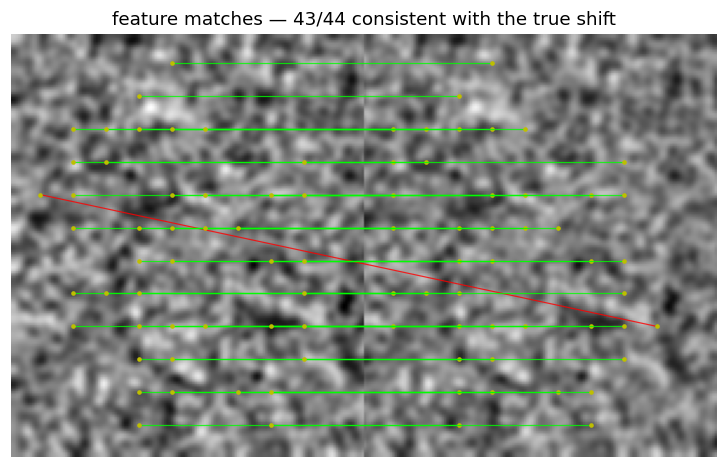

correct matches: 43/44 (green = consistent, red = outlier)


In [7]:
# eşleşmeleri iki görünüm arasında görselleştir
canvas = np.hstack([view1, view2]); off = view1.shape[1]
fig, ax = plt.subplots(figsize=(11, 5)); ax.imshow(canvas, cmap="gray")
correct = 0
for (i, j) in matches:
    x1, y1 = kp1[i]; x2, y2 = kp2[j]
    dx = (x2 + off) - x1
    ok = abs((x1 - x2) - shift) <= 3 and abs(y1 - y2) <= 3   # beklenen kayma
    correct += ok
    ax.plot([x1, x2 + off], [y1, y2], "-", color=("lime" if ok else "red"), lw=0.8, alpha=0.8)
    ax.plot(x1, y1, "y.", ms=4); ax.plot(x2 + off, y2, "y.", ms=4)
ax.set_title(f"öznitelik eşleşmeleri — {correct}/{len(matches)} gerçek kaymayla tutarlı")
ax.axis("off"); plt.show()
print(f"doğru eşleşmeler: {correct}/{len(matches)} (yeşil = tutarlı, kırmızı = aykırı değer)")

## 6. Where this shows up in modern vision

- **Panoramas & SfM.** Detect → describe → match → estimate geometry is exactly how panorama stitching
  and structure-from-motion recover camera poses and 3D points.
- **Learned local features.** SuperPoint, D2-Net, and DISK replace hand-built detectors/descriptors with
  CNNs, and learned matchers like SuperGlue replace the nearest-neighbor + ratio test — but the
  *pipeline shape* is unchanged.
- **The ratio test survives.** Lowe's ratio idea still appears as a confidence filter even in deep
  matching systems.

Preview: descriptor distance as a matching score — the quantity a learned matcher optimizes.

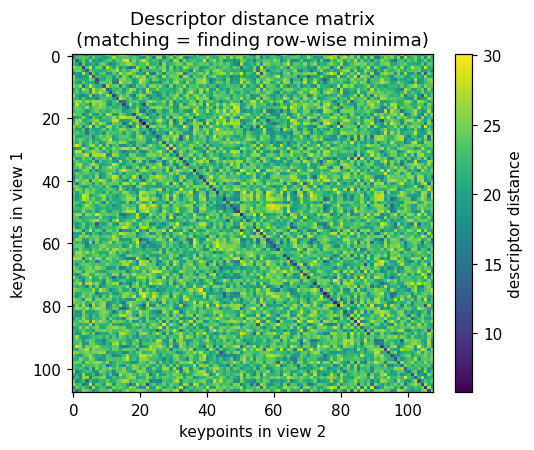

In [8]:
# iki betimleyici kümesi arasındaki mesafe matrisi: eşleşmeler koyu köşegen-benzeri minimumlardır
D = np.array([[np.linalg.norm(d1 - d2) for d2 in desc2] for d1 in desc1])
plt.figure(figsize=(5, 4.2))
plt.imshow(D, cmap="viridis", aspect="auto")
plt.colorbar(label="betimleyici mesafesi")
plt.xlabel("view 2'deki anahtar noktalar"); plt.ylabel("view 1'deki anahtar noktalar")
plt.title("Betimleyici mesafe matrisi\n(eşleştirme = satır bazında minimumları bulma)")
plt.tight_layout(); plt.show()

## Exercises

1. **Ratio threshold.** Sweep Lowe's ratio from 0.5 to 0.95 and plot match count vs correctness. What trade-off appears?
2. **Rotation robustness.** Rotate view 2 slightly. Does the raw-patch descriptor survive? Explain why SIFT's orientation normalization is needed.
3. **Blob count vs threshold.** Vary the blob detection threshold and relate the count to the four known blobs in §1.

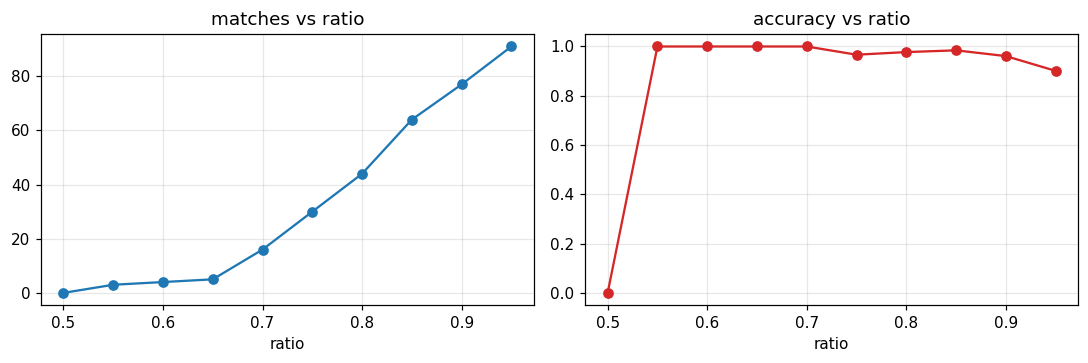

Looser ratio → more matches but more outliers; stricter ratio → fewer, cleaner matches.


In [9]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. oran testi ödünleşimi
ratios = np.linspace(0.5, 0.95, 10)
counts, accs = [], []
for r in ratios:
    m = match(desc1, desc2, ratio=r)
    ok = sum(abs((kp1[i][0]-kp2[j][0]) - shift) <= 3 and abs(kp1[i][1]-kp2[j][1]) <= 3 for i, j in m)
    counts.append(len(m)); accs.append(ok / max(len(m), 1))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(ratios, counts, "o-", color="C0"); ax[0].set_title("eşleşmeler vs oran"); ax[0].set_xlabel("oran"); ax[0].grid(alpha=0.3)
ax[1].plot(ratios, accs, "o-", color="C3"); ax[1].set_title("doğruluk vs oran"); ax[1].set_xlabel("oran"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Gevşek oran → daha fazla eşleşme ama daha fazla aykırı değer; katı oran → daha az, daha temiz eşleşme.")

## Recap & what's next

Blob detection adds the scale axis Harris lacked: maxima in the $(x,y,\sigma)$ DoG volume locate blobs
*and* their size. Descriptors turn a keypoint into a comparable vector, and nearest-neighbor matching
with Lowe's ratio test links keypoints across views — the classic detect/describe/match pipeline.

**Next — `09_segmentation_hough_kmeans.ipynb`:** we shift from points to *regions*, grouping pixels by
color with k-means and finding global shapes like lines with the Hough transform.

---
*Computer Vision · Week 4 · Lecture 8*